# SPEED Pose Estimation Visualization Demo

This notebook demonstrates how to use the enhanced visualization system for your SPEED pose estimation results.

In [1]:
import matplotlib.pyplot as plt
from visualization import (
    PoseVisualizationSystem,
    quick_visualize_sample,
    compare_samples_grid,
)
from src.datasets import SPEEDDataset

# Set up plotting
%matplotlib inline
plt.style.use("default")

print("Visualization system loaded successfully!")

Visualization system loaded successfully!


## 1. Quick Start - Dashboard Overview

Let's start by creating an overall dashboard of your results:

In [2]:
# Path to your results
results_path = "../results.json"
DATASET_NAME = "SPEED_PLUS"

# Create dataset instance to load images
# First, initialize the dataset to load actual images
dataset = SPEEDDataset(dataset_root_dir="../SPEED_PLUS_FIXED", split="test")

if dataset is None:
    print("Could not load dataset, will try to load images directly from filesystem")

# viz_system = create_dashboard(results_path, output_html="pose_results_dashboard.html")

## 2. Single Sample Visualization

Let's look at individual samples in detail:

Loaded original image: ../SPEED_PLUS_FIXED/images/test/img000001_lightbox.jpg (1920x1200)

Sample 0: Image bounds: x=(np.float64(0.0), np.float64(1920.0)), y=(np.float64(1200.0), np.float64(0.0))
GT quaternion: [-0.15248353779315948, 0.3015994131565094, 0.9372867941856384, 0.08532288670539856]
GT translation: [-0.06031113862991333, 0.14628387987613678, 2.6972243785858154]
Pred quaternion: [-0.1356526017189026, 0.30901429057121277, 0.9375802278518677, 0.08397594839334488]
Pred translation: [-0.06431176513433456, 0.15322908759117126, 2.7500338554382324]
GT projection: x=[ 892.84234809  136.64686837 1536.83262344  456.63273199], y=[ 762.89000852 1278.60222203 1631.62513714 1280.19419427]
Pred projection: x=[ 889.76275943  137.94766007 1532.16556379  515.08908063], y=[ 767.34711394 1297.61218685 1608.50225759 1257.96180585]
  X-axis: GT(136.6, 1278.6), Pred(137.9, 1297.6)
  Y-axis: GT(1536.8, 1631.6), Pred(1532.2, 1608.5)
  Z-axis: GT(456.6, 1280.2), Pred(515.1, 1258.0)
  Pose center dista

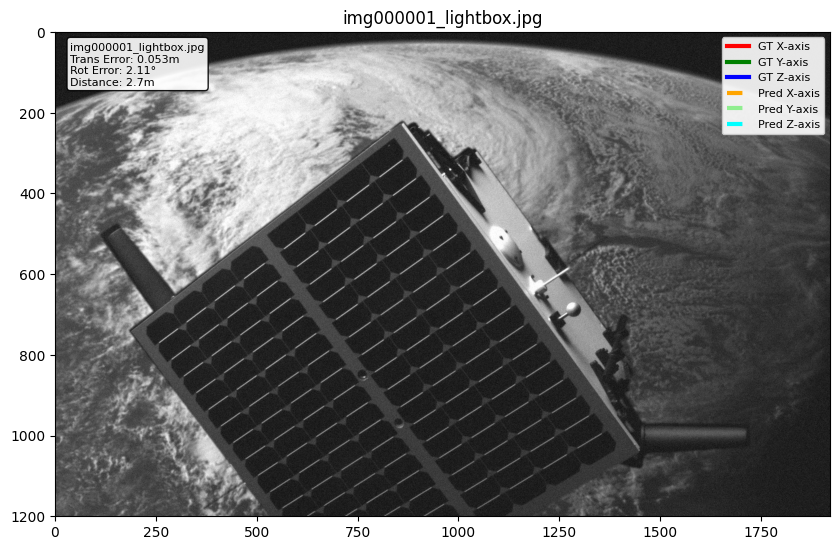

Sample 0 visualization complete.
Red/Green/Blue arrows show X/Y/Z axes respectively.
Solid lines = Ground Truth, Dashed lines = Prediction


In [3]:
# Visualize sample 0
sample_id = "0"
fig = quick_visualize_sample(results_path, sample_id, dataset_name=DATASET_NAME)
plt.show()

print(f"Sample {sample_id} visualization complete.")
print("Red/Green/Blue arrows show X/Y/Z axes respectively.")
print("Solid lines = Ground Truth, Dashed lines = Prediction")

## 3. Multiple Sample Comparison Grid

Compare multiple samples at once:

Loaded original image: ../SPEED_PLUS_FIXED/images/test/img000001_lightbox.jpg (1920x1200)

Sample 0: Image bounds: x=(np.float64(0.0), np.float64(1920.0)), y=(np.float64(1200.0), np.float64(0.0))
GT quaternion: [-0.15248353779315948, 0.3015994131565094, 0.9372867941856384, 0.08532288670539856]
GT translation: [-0.06031113862991333, 0.14628387987613678, 2.6972243785858154]
Pred quaternion: [-0.1356526017189026, 0.30901429057121277, 0.9375802278518677, 0.08397594839334488]
Pred translation: [-0.06431176513433456, 0.15322908759117126, 2.7500338554382324]
GT projection: x=[ 892.84234809  136.64686837 1536.83262344  456.63273199], y=[ 762.89000852 1278.60222203 1631.62513714 1280.19419427]
Pred projection: x=[ 889.76275943  137.94766007 1532.16556379  515.08908063], y=[ 767.34711394 1297.61218685 1608.50225759 1257.96180585]
  X-axis: GT(136.6, 1278.6), Pred(137.9, 1297.6)
  Y-axis: GT(1536.8, 1631.6), Pred(1532.2, 1608.5)
  Z-axis: GT(456.6, 1280.2), Pred(515.1, 1258.0)
  Pose center dista

/home/pierre/Desktop/SimpleViT6D/other_utils/visualization.py:644: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend().set_visible(False)  # Hide individual legends


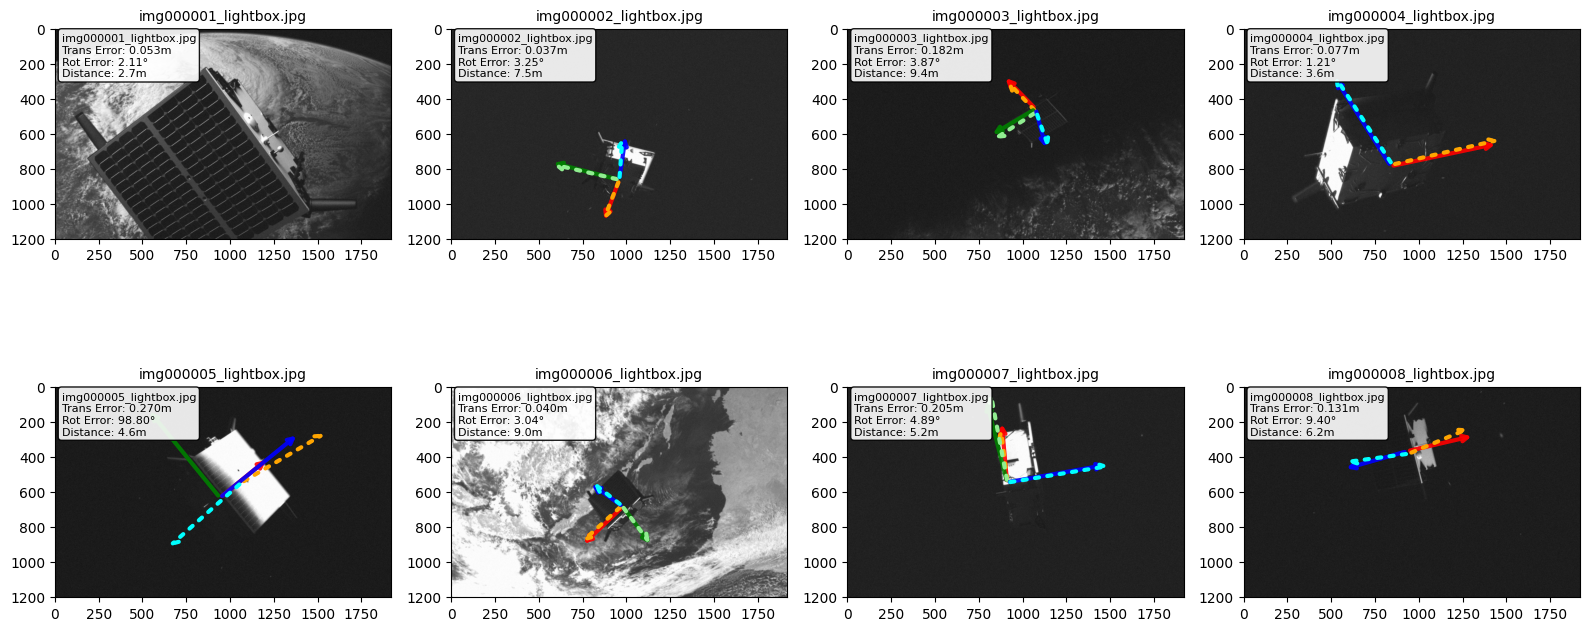

In [4]:
# Create a grid of 8 samples
fig = compare_samples_grid(results_path, n_samples=8, dataset=None, dataset_name=DATASET_NAME)
plt.show()

## 4. Detailed Error Analysis

Let's dive deeper into the error analysis:

In [5]:
# Initialize visualization system
viz = PoseVisualizationSystem(results_path)

# Get summary statistics
summary = viz.generate_summary_report()

print("=== Detailed Error Analysis ===")
print(f"Total samples analyzed: {summary['total_samples']}")
print("\nTranslation Error Statistics (meters):")
for key, value in summary["translation_error"].items():
    print(f"  {key.capitalize()}: {value:.4f}")

print("\nRotation Error Statistics (degrees):")
for key, value in summary["rotation_error"].items():
    print(f"  {key.capitalize()}: {value:.2f}")

=== Detailed Error Analysis ===
Total samples analyzed: 9532

Translation Error Statistics (meters):
  Mean: 0.2754
  Std: 0.5331
  Median: 0.1268
  Min: 0.0009
  Max: 10.8023
  Percentile_95: 0.9754

Rotation Error Statistics (degrees):
  Mean: 15.30
  Std: 34.22
  Median: 4.34
  Min: 0.12
  Max: 179.99
  Percentile_95: 100.80


## 5. Find Best and Worst Performing Samples

Identify samples with best and worst performance:

In [6]:
# Find best and worst samples
trans_errors = {sid: metrics["translation_error_m"] for sid, metrics in viz.error_metrics.items()}
rot_errors = {sid: metrics["rotation_error_deg"] for sid, metrics in viz.error_metrics.items()}

# Best and worst translation
best_trans = min(trans_errors, key=trans_errors.get)
worst_trans = max(trans_errors, key=trans_errors.get)

# Best and worst rotation
best_rot = min(rot_errors, key=rot_errors.get)
worst_rot = max(rot_errors, key=rot_errors.get)

best_worst = viz.get_best_worst_samples()

print("=== Best and Worst Performing Samples ===")
print("Best translation accuracy:")
print(f"  Sample ID: {best_worst['best_translation']['sample_id']}")
print(f"  Filename: {best_worst['best_translation']['filename']}")
print(f"  Error: {best_worst['best_translation']['error']:.4f}m")

print("\nWorst translation accuracy:")
print(f"  Sample ID: {best_worst['worst_translation']['sample_id']}")
print(f"  Filename: {best_worst['worst_translation']['filename']}")
print(f"  Error: {best_worst['worst_translation']['error']:.4f}m")

print("\nBest rotation accuracy:")
print(f"  Sample ID: {best_worst['best_rotation']['sample_id']}")
print(f"  Filename: {best_worst['best_rotation']['filename']}")
print(f"  Error: {best_worst['best_rotation']['error']:.2f}°")

print("\nWorst rotation accuracy:")
print(f"  Sample ID: {best_worst['worst_rotation']['sample_id']}")
print(f"  Filename: {best_worst['worst_rotation']['filename']}")
print(f"  Error: {best_worst['worst_rotation']['error']:.2f}°")

=== Best and Worst Performing Samples ===
Best translation accuracy:
  Sample ID: 1786
  Filename: sample_1786.jpg
  Error: 0.0009m

Worst translation accuracy:
  Sample ID: 1376
  Filename: sample_1376.jpg
  Error: 10.8023m

Best rotation accuracy:
  Sample ID: 4269
  Filename: sample_4269.jpg
  Error: 0.12°

Worst rotation accuracy:
  Sample ID: 4421
  Filename: sample_4421.jpg
  Error: 179.99°


## 6. Visualize Best vs Worst Samples

Let's compare the best and worst performing samples:

Best translation: img001787_lightbox.jpg (Error: 0.0009m)
Worst translation: img001377_lightbox.jpg (Error: 10.8023m)
Best rotation: img004270_lightbox.jpg (Error: 0.12°)
Worst rotation: img004422_lightbox.jpg (Error: 179.99°)
Loaded original image: ../SPEED_PLUS_FIXED/images/test/img001787_lightbox.jpg (1920x1200)

Sample 1786: Image bounds: x=(np.float64(0.0), np.float64(1920.0)), y=(np.float64(1200.0), np.float64(0.0))
GT quaternion: [-0.20827801525592804, -0.3930644690990448, -0.18468721210956573, 0.8763625025749207]
GT translation: [0.15475229918956757, 0.5387121438980103, 8.043049812316895]
Pred quaternion: [-0.22070901095867157, -0.38320228457450867, -0.18517881631851196, 0.8775833249092102]
Pred translation: [0.15541286766529083, 0.5384626388549805, 8.043662071228027]
GT projection: x=[1017.78716697  774.48856025 1213.35951352  801.52615035], y=[801.16436892 731.59298557 483.29755288 617.77020783]
Pred projection: x=[1018.02941722  773.15577785 1220.71725962  809.35882454], y=[

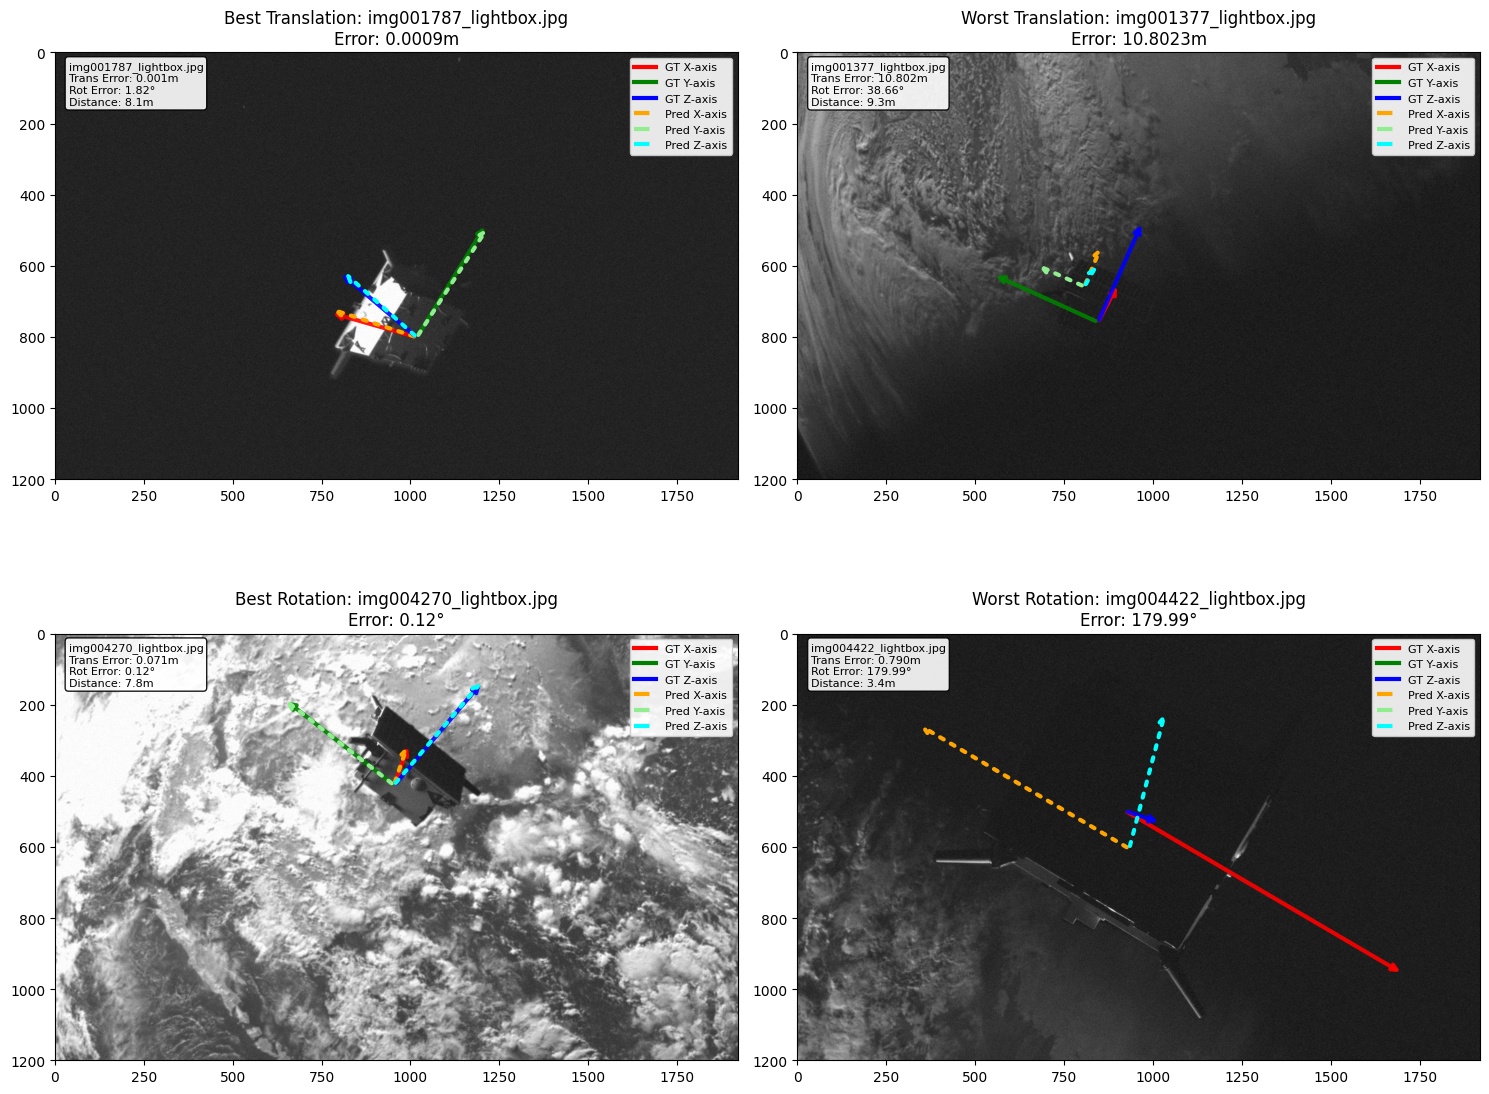

In [7]:
# Initialize visualization system with correct dataset
viz = PoseVisualizationSystem(results_path, dataset_name=DATASET_NAME)

# Get best/worst samples
best_worst = viz.get_best_worst_samples()

# Extract sample IDs
best_trans = best_worst["best_translation"]["sample_id"]
worst_trans = best_worst["worst_translation"]["sample_id"]
best_rot = best_worst["best_rotation"]["sample_id"]
worst_rot = best_worst["worst_rotation"]["sample_id"]

print(
    f"Best translation: {best_worst['best_translation']['filename']} (Error: {best_worst['best_translation']['error']:.4f}m)"
)
print(
    f"Worst translation: {best_worst['worst_translation']['filename']} (Error: {best_worst['worst_translation']['error']:.4f}m)"
)
print(
    f"Best rotation: {best_worst['best_rotation']['filename']} (Error: {best_worst['best_rotation']['error']:.2f}°)"
)
print(
    f"Worst rotation: {best_worst['worst_rotation']['filename']} (Error: {best_worst['worst_rotation']['error']:.2f}°)"
)

# Create comparison plot WITH satellite images
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Best translation - WITH IMAGE
viz.visualize_sample_comparison(best_trans, ax=axes[0, 0], show_image=True)
axes[0, 0].set_title(
    f"Best Translation: {best_worst['best_translation']['filename']}\nError: {best_worst['best_translation']['error']:.4f}m"
)

# Worst translation - WITH IMAGE
viz.visualize_sample_comparison(worst_trans, ax=axes[0, 1], show_image=True)
axes[0, 1].set_title(
    f"Worst Translation: {best_worst['worst_translation']['filename']}\nError: {best_worst['worst_translation']['error']:.4f}m"
)

# Best rotation - WITH IMAGE
viz.visualize_sample_comparison(best_rot, ax=axes[1, 0], show_image=True)
axes[1, 0].set_title(
    f"Best Rotation: {best_worst['best_rotation']['filename']}\nError: {best_worst['best_rotation']['error']:.2f}°"
)

# Worst rotation - WITH IMAGE
viz.visualize_sample_comparison(worst_rot, ax=axes[1, 1], show_image=True)
axes[1, 1].set_title(
    f"Worst Rotation: {best_worst['worst_rotation']['filename']}\nError: {best_worst['worst_rotation']['error']:.2f}°"
)

plt.tight_layout()
plt.show()

## 7. Distance-based Analysis

Analyze how accuracy relates to satellite distance:

=== Error by Distance Category ===
             translation_error               rotation_error         
                          mean     std count           mean      std
distance_bin                                                        
Very Close              0.1328  0.1936  1853        14.1692  32.3484
Close                   0.1855  0.3183  1939        12.9366  30.0780
Medium                  0.2565  0.4453  1904        15.3973  34.9391
Far                     0.3290  0.5772  1947        15.5237  34.9073
Very Far                0.4714  0.8251  1888        18.5142  38.1168


/tmp/ipykernel_141748/3199844356.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("distance_bin")


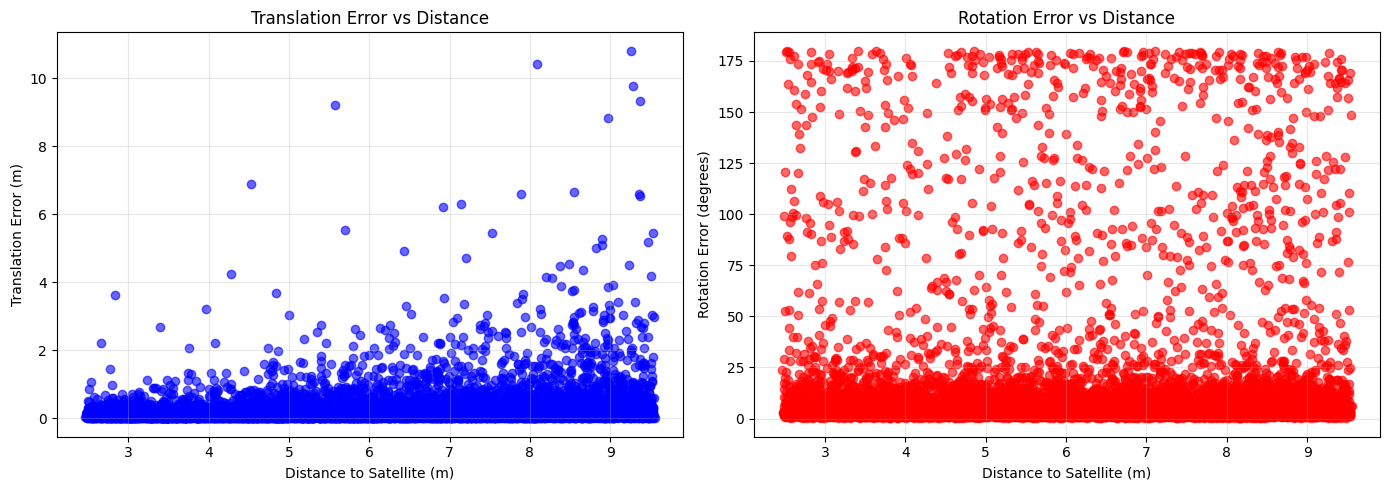

In [8]:
import pandas as pd

# Create DataFrame for analysis
data = []
for sid, metrics in viz.error_metrics.items():
    data.append(
        {
            "sample_id": int(sid),
            "translation_error": metrics["translation_error_m"],
            "rotation_error": metrics["rotation_error_deg"],
            "distance": metrics["distance_to_satellite"],
        }
    )

df = pd.DataFrame(data)

# Distance bins
df["distance_bin"] = pd.cut(
    df["distance"], bins=5, labels=["Very Close", "Close", "Medium", "Far", "Very Far"]
)

# Group statistics
distance_stats = (
    df.groupby("distance_bin")
    .agg({"translation_error": ["mean", "std", "count"], "rotation_error": ["mean", "std"]})
    .round(4)
)

print("=== Error by Distance Category ===")
print(distance_stats)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Translation error vs distance
axes[0].scatter(df["distance"], df["translation_error"], alpha=0.6, color="blue")
axes[0].set_xlabel("Distance to Satellite (m)")
axes[0].set_ylabel("Translation Error (m)")
axes[0].set_title("Translation Error vs Distance")
axes[0].grid(True, alpha=0.3)

# Rotation error vs distance
axes[1].scatter(df["distance"], df["rotation_error"], alpha=0.6, color="red")
axes[1].set_xlabel("Distance to Satellite (m)")
axes[1].set_ylabel("Rotation Error (degrees)")
axes[1].set_title("Rotation Error vs Distance")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()